In [33]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.datasets import Flowers102
from torchvision import transforms
from torch.utils.data import DataLoader, ConcatDataset

import matplotlib.pyplot as plt
import torchvision.utils as vutils
from torchvision.utils import save_image
import numpy as np
from tqdm import tqdm
import pandas as pd

In [34]:
from google.colab import drive

drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/WCGAN_GP_Flowers102'
os.makedirs(DRIVE_PATH, exist_ok=True)
os.makedirs(f"{DRIVE_PATH}/output/wcgan-gp-images", exist_ok=True)
os.makedirs(f"{DRIVE_PATH}/output/wcgan-gp-ckpts", exist_ok=True)

print(f"Google Drive mounted at: {DRIVE_PATH}")

In [36]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# WCGAN-GP HYPERPARAMETERS
LATENT_DIM = 100
IMG_SHAPE = (3, 64, 64)  # (c, h, w)
BATCH_SIZE = 128
LR_G = 0.0002       
LR_D = 0.00005      
EPOCHS = 150
NUM_CLASSES = 102
EMBEDDING_DIM = 50


GRADIENT_PENALTY_WEIGHT = 10  # Lambda for gradient penalty
CRITIC_ITERATIONS = 5        

SAMPLE_INTERVAL = 200  # generate validation samples every N steps
CKPT_INTERVAL = 5      # save ckpt every M epochs

print(f"Device: {DEVICE}")
print(f"LATENT_DIM: {LATENT_DIM}")
print(f"IMG_SHAPE: {IMG_SHAPE}")
print(f"BATCH_SIZE: {BATCH_SIZE}")
print(f"EPOCHS: {EPOCHS}")
print(f"GRADIENT_PENALTY_WEIGHT: {GRADIENT_PENALTY_WEIGHT}")
print(f"CRITIC_ITERATIONS: {CRITIC_ITERATIONS}")

In [37]:
# DEFINE THE GENERATOR ARCHITECTURE 

class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim=100, num_classes=102, embedding_dim=50):
        super().__init__()
        self.embedding = nn.Embedding(num_classes, embedding_dim)
        self.fc = nn.Sequential(
            nn.Linear(latent_dim + embedding_dim, 512),    
            nn.BatchNorm1d(512),                            
            nn.ReLU(True),
            nn.Linear(512, 1024),                          
            nn.BatchNorm1d(1024),                          
            nn.ReLU(True),
            nn.Linear(1024, 8192),                         
            nn.BatchNorm1d(8192),                          
            nn.ReLU(True),
        )
        self.conv_layers = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),  
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),   
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),   
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),     
            nn.Tanh()
        )
    def forward(self, z, labels):
        x = torch.cat([z, self.embedding(labels)], dim=1)
        x = self.fc(x)
        x = x.view(-1, 512, 4, 4)   
        out = self.conv_layers(x) 
        return out



In [38]:
class ConditionalCritic(nn.Module):
    def __init__(self, num_classes, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_classes, embedding_dim)
        
        def critic_block(in_channels, out_channels, norm=True):
            layers = [nn.Conv2d(in_channels, out_channels, 4, 2, 1)]
            if norm:
                layers.append(nn.InstanceNorm2d(out_channels, affine=True))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)

        self.model = nn.Sequential(
            critic_block(3, 128, norm=False), # 64 -> 32
            critic_block(128, 256),           # 32 -> 16
            critic_block(256, 512),           # 16 -> 8
            critic_block(512, 1024),          # 8 -> 4
        )
        
        self.fc = nn.Sequential(
            nn.Linear(1024 * 4 * 4 + embedding_dim, 1) 
        )

    def forward(self, img, labels):
        features = self.model(img)
        features = features.view(features.size(0), -1)
        emb = self.embedding(labels)
        d_in = torch.cat((features, emb), dim=1)
        return self.fc(d_in)

In [39]:
# GRADIENT PENALTY FUNCTION FOR WGAN-GP

def compute_gradient_penalty(critic, real_images, fake_images, labels, device, lambda_gp=10):
   
    batch_size = real_images.size(0)
    
    # Generate random interpolation coefficient
    alpha = torch.rand(batch_size, 1, 1, 1).to(device)
    
    # Interpolate between real and fake images
    interpolates = (alpha * real_images + (1 - alpha) * fake_images).requires_grad_(True)
    
    # Get critic output for interpolated images
    critic_output = critic(interpolates, labels)
    
    # Compute gradients
    gradients = torch.autograd.grad(
        outputs=critic_output,
        inputs=interpolates,
        grad_outputs=torch.ones_like(critic_output),
        create_graph=True,
        retain_graph=True
    )[0]
    
    # Reshape gradients
    gradients = gradients.view(batch_size, -1)
    
    # Compute norm of gradients
    gradient_norms = torch.norm(gradients, p=2, dim=1)
    
    # Gradient penalty: (||gradient|| - 1)^2
    gradient_penalty = torch.mean((gradient_norms - 1) ** 2)
    
    return lambda_gp * gradient_penalty

In [40]:
# Initialize generator and critic
generator = ConditionalGenerator(LATENT_DIM, NUM_CLASSES, EMBEDDING_DIM).to(DEVICE)
critic = ConditionalCritic(NUM_CLASSES, EMBEDDING_DIM).to(DEVICE)

print(f"Generator: {sum(p.numel() for p in generator.parameters()):,} params")
print(f"Critic: {sum(p.numel() for p in critic.parameters()):,} params")

In [41]:
# DEFINE THE TRANSFORMS TO APPLY TO IMAGES

transform = transforms.Compose([
    transforms.Resize(64), 
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = Flowers102(root='./data', split='train', download=True, transform=transform)
val_set = Flowers102(root='./data', split='val', download=True, transform=transform)
test_set = Flowers102(root='./data', split='test', download=True, transform=transform)

# CONCAT THE 3 PROVIDED SPLITS TO GET A LARGER TRAINING SET
full_set = ConcatDataset([train_set, val_set, test_set])

print("Train set: ", len(train_set))
print("Validation set: ", len(val_set))
print("Test set: ", len(test_set))
print("Full set: ", len(full_set))

if hasattr(train_set, "classes"):
    CLASSES = train_set.classes
    print("Number of classes: ", len(set(CLASSES)))

In [42]:
# DEFINE DATALOADERS

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

full_loader = DataLoader(full_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print(f"Full loader batches: {len(full_loader)}")

Full loader batches: 128


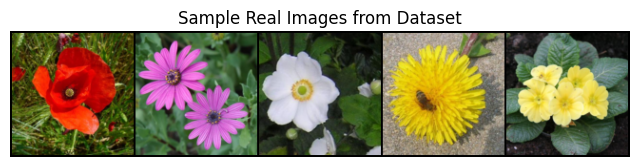

In [43]:
# Visualize a batch
images, labels = next(iter(train_loader))

# make a grid
grid = vutils.make_grid(images[:5], nrow=5, normalize=True)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Sample Real Images from Dataset")
plt.show()

In [44]:
# Optimizers - using Adam as per WGAN-GP paper suggestions
optimizer_G = optim.Adam(generator.parameters(), lr=LR_G, betas=(0.5, 0.999))
optimizer_C = optim.Adam(critic.parameters(), lr=LR_D, betas=(0.5, 0.999))

In [ ]:

fixed_z = torch.randn(25, LATENT_DIM).to(DEVICE)
fixed_labels = (torch.arange(0, 25) % NUM_CLASSES).to(DEVICE)


g_losses, c_losses, gp_losses, wasserstein_distances = [], [], [], []

for epoch in range(EPOCHS):
    for i, (real_images, labels) in enumerate(full_loader):
        real_images, labels = real_images.to(DEVICE), labels.to(DEVICE)
        batch_size = real_images.size(0)

        # ---------------------
        #  Train Critic
        # ---------------------
        for _ in range(CRITIC_ITERATIONS):
            optimizer_C.zero_grad()
            real_output = critic(real_images, labels)
            
            z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
            fake_images = generator(z, labels)
            fake_output = critic(fake_images.detach(), labels)
            
            wd = torch.mean(real_output) - torch.mean(fake_output)
            gp = compute_gradient_penalty(critic, real_images, fake_images.detach(), labels, DEVICE, GRADIENT_PENALTY_WEIGHT)
            
            c_loss = -wd + gp
            c_loss.backward()
            optimizer_C.step()

        c_losses.append(c_loss.item())
        gp_losses.append(gp.item())
        wasserstein_distances.append(wd.item())

        # -----------------
        #  Train Generator
        # -----------------
        optimizer_G.zero_grad()
        fake_images = generator(torch.randn(batch_size, LATENT_DIM).to(DEVICE), labels)
        g_loss = -torch.mean(critic(fake_images, labels))
        g_loss.backward()
        optimizer_G.step()
        g_losses.append(g_loss.item())

        
        if (i + 1) % 50 == 0:
            print(f"[Epoch {epoch}/{EPOCHS}] [Batch {i}/{len(full_loader)}] "
                  f"[WD: {wd.item():.4f}] [GP: {gp.item():.4f}]")

  
    generator.eval()
    with torch.no_grad():
        sample = generator(fixed_z, fixed_labels)
    save_image(sample, f"{DRIVE_PATH}/output/wcgan-gp-images/epoch_{epoch+1}.jpg", nrow=5, normalize=True)
    generator.train()

  
    if (epoch + 1) % 5 == 0 or (epoch + 1) == EPOCHS:
        torch.save(generator.state_dict(), f"{DRIVE_PATH}/output/wcgan-gp-ckpts/generator_weights_ep-{epoch+1}.pth")
        torch.save(critic.state_dict(), f"{DRIVE_PATH}/output/wcgan-gp-ckpts/critic_weights_ep-{epoch+1}.pth")
        
        metrics_dir = f"{DRIVE_PATH}/output/wcgan-gp-ckpts/metrics"
        os.makedirs(metrics_dir, exist_ok=True)
        metrics_df = pd.DataFrame({
            'g_losses': g_losses,
            'c_losses': c_losses,
            'gp_losses': gp_losses,
            'wasserstein_distances': wasserstein_distances
        })
        csv_save_path = f"{metrics_dir}/metrics.csv"
        metrics_df.to_csv(csv_save_path, index=False)

In [46]:
# PLOT WGAN-GP LOSSES

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

csv_path = f"{DRIVE_PATH}/output/wcgan-gp-ckpts/metrics/metrics.csv" 
df = pd.read_csv(csv_path)

# Generator Loss
axes[0, 0].plot(df['g_losses'], label='Generator Loss', color='blue')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Generator Loss')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Critic Loss
axes[0, 1].plot(df['c_losses'], label='Critic Loss', color='red')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Critic Loss')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Gradient Penalty
axes[1, 0].plot(df['gp_losses'], label='Gradient Penalty', color='green')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('GP Loss')
axes[1, 0].set_title('Gradient Penalty')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Wasserstein Distance
axes[1, 1].plot(df['wasserstein_distances'], label='Wasserstein Distance', color='purple')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('W-distance')
axes[1, 1].set_title('Wasserstein Distance')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/losses_wcgan_gp.jpg', dpi=150)
plt.show()

In [53]:
from torchvision.utils import make_grid
import os
import torch
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


epochs_to_compare = [0, 10, 50, 100, 135, 150]
num_samples = 8
nrow = 8

fig, axes = plt.subplots(len(epochs_to_compare) + 1, 1, figsize=(15, 3 * (len(epochs_to_compare) + 1)))

# --- REAL IMAGES ---
try:
    real_batch, _ = next(iter(full_loader))
    real_grid = make_grid(real_batch[:num_samples], nrow=nrow, normalize=True)
    axes[0].imshow(real_grid.permute(1, 2, 0).cpu())
    axes[0].set_title("Real images from dataset", fontsize=14, fontweight='bold')
except Exception as e:
    axes[0].text(0.5, 0.5, f"Dataloader error: {e}", ha='center', va='center')
axes[0].axis("off")

# --- FIXED NOISE ---
fixed_z_path = "/content/drive/MyDrive/DCGAN_Flowers102/output/fixed_z.pt"
if os.path.exists(fixed_z_path):
    fixed_z = torch.load(fixed_z_path, map_location=device)
    if fixed_z.dim() == 4:
        fixed_z = fixed_z.view(fixed_z.size(0), -1)
    fixed_z_subset = fixed_z[:num_samples]
else:
    fixed_z_subset = torch.randn(num_samples, LATENT_DIM, device=device)

fixed_labels = torch.arange(0, num_samples, dtype=torch.long, device=device)

# --- GENERATED IMAGES PER EPOCH ---
for i, ep in enumerate(epochs_to_compare):
    idx = i + 1
    path = f"{DRIVE_PATH}/output/wcgan-gp-ckpts/generator_weights_ep-{ep}.pth"

    if ep == 0:
        gen_model = ConditionalGenerator(LATENT_DIM, NUM_CLASSES, EMBEDDING_DIM).to(device)
        title = "Epoch 0 (Random Init)"
        found = True
    elif os.path.exists(path):
        gen_model = ConditionalGenerator(LATENT_DIM, NUM_CLASSES, EMBEDDING_DIM).to(device)
        gen_model.load_state_dict(torch.load(path, map_location=device))
        title = f"Epoch {ep}"
        found = True
    else:
        print(f"Checkpoint not found: {path}")
        found = False
        gen_model = None

    if found:
        gen_model.eval()
        with torch.no_grad():
            fake_batch = gen_model(fixed_z_subset, fixed_labels)
        fake_grid = make_grid(fake_batch.cpu(), nrow=nrow, normalize=True)
        axes[idx].imshow(fake_grid.permute(1, 2, 0))
        axes[idx].set_title(title, fontsize=12)
    else:
        axes[idx].text(0.5, 0.5, f"Epoch {ep} not available", ha='center', va='center')

    axes[idx].axis("off")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("WCGAN-GP: Quality Progression", fontsize=18)
save_path = f"{DRIVE_PATH}/wcgan_gp_evolution.jpg"
plt.savefig(save_path, bbox_inches='tight', dpi=150)
print(f"Saved: {save_path}")
plt.show()